In [15]:
import numpy as np
import pandas as pd
import nitools as nit
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.globals as gl
import Functional_Fusion.dataset as fdata
import Functional_Fusion.atlas_map as am
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.evaluation as ev
import SUITPy as suit

In [4]:
# the atlas
atlas_img = nib.load(gl.atlas_dir + "/tpl-MNI152NLin6Asym/atl-Platchi5_space-MNI152NLin6Asym_dseg.nii")
atlas_data = atlas_img.get_fdata().squeeze()

In [5]:
config = rm.get_train_config(log_alpha=0,
                                 crossed='half',
                                 type='CondHalf',
                                 cond_num='all',
                                 subj_list='all',
                                 cerebellum='MNISymC3',
                                 parcellation='Icosahedron1002',
                                 train_dataset='MDTB',
                                 method='NNLS',
                                 train_ses='all',
                                 add_rest=False,
                                 std_cortex='parcel',
                                 std_cerebellum='global',
                                 cortical_cerebellar_act='ind',
                                 append=False)

In [6]:
subj = rm.get_subj_list('all', 'MDTB')

# Load the data
HH, info, _ = fdata.get_dataset(gl.base_dir,
                                   'MDTB',
                                   sess='all',
                                   subj=subj,
                                   atlas='MNIAsymHippocampus',
                                   type=config["type"])

HH, info = rm.prepare_data(HH, info, config)
for i in range(HH.shape[0]):
    if 'std_cortex' in config.keys():
        HH[i,:,:] = rm.std_data(HH[i,:,:], config['std_cortex'])
H = HH.mean(axis=0)

YY, info, _ = fdata.get_dataset(gl.base_dir,
                                   'MDTB',
                                   sess='all',
                                   subj=subj,
                                   atlas=config['cerebellum'],
                                   type=config["type"])

YY, info = rm.prepare_data(YY, info, config)
for i in range(YY.shape[0]):
    if 'std_cerebellum' in config.keys():
        YY[i,:,:] = rm.std_data(YY[i,:,:], config['std_cerebellum'])
Y = YY.mean(axis=0)

/home/UWO/ashahb7/Github/cortico_cereb_connectivity/cortico_cereb_connectivity/run_model.py:395: RuntimeWarning: invalid value encountered in divide
  return  np.nan_to_num(Y/sc)


In [7]:
print(atlas_data.shape)
print(H.shape)
print(f"Number of labeled Hippocampal voxels: {np.sum(atlas_data > 0)}")
print(Y.shape)

(91, 109, 91)
(122, 1559)
Number of labeled Hippocampal voxels: 1559
(122, 5446)


In [8]:
# should already be zero mean
A = H - H.mean(axis=0, keepdims=True)
B = Y - Y.mean(axis=0, keepdims=True)

A /= np.linalg.norm(A, axis=0, keepdims=True) # should already be norm 1
B /= np.linalg.norm(B, axis=0, keepdims=True)

corr = A.T @ B

/localscratch/tmp/ipykernel_355090/1897872440.py:6: RuntimeWarning: invalid value encountered in divide
  B /= np.linalg.norm(B, axis=0, keepdims=True)


In [9]:
print(corr.shape)

(1559, 5446)


<Axes: >

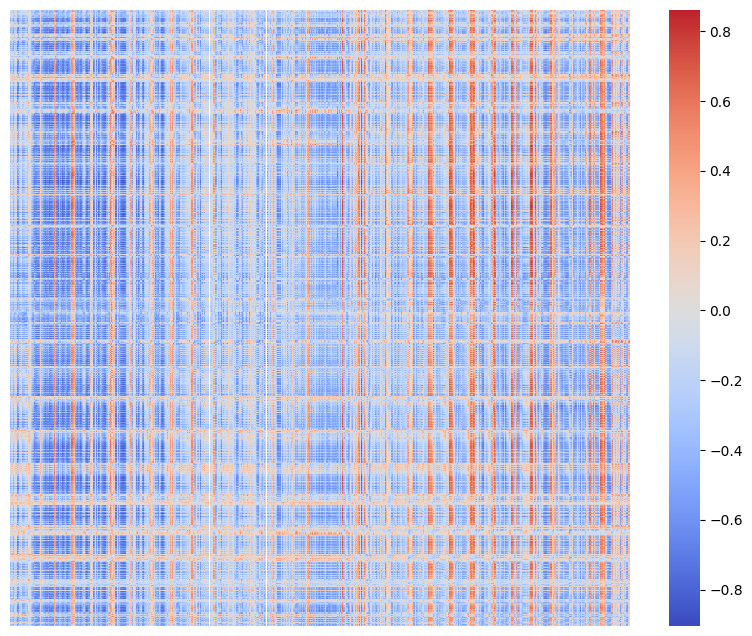

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False)

In [ ]:
atlas,ainf = am.get_atlas('MNISymC3')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i in range(1, 6):
    corr_vec = corr[atlas_data == i, :].mean(axis=0)
    nifti_image = atlas.data_to_nifti(corr_vec)
    data = suit.vol_to_surf(nifti_image, space='MNISymC')

    axes.flat[i-1].subplot(2, 3, i)
    suit.flatmap.plot(data, cmap='rocket', new_figure=False, cscale=[-1, 1])
    axes.flat[i-1].set_title(f'Region {i}', fontsize=11)